/var/folders/wf/99_6t8ks1k9d8j0hnn8j65gc0000gn/T/ipykernel_368/460627645.py:9: DtypeWarning: Columns (0: terminal_observation) have mixed types. Specify dtype option on import or set low_memory=False.
  ppo = pd.read_csv("ppo_rl_simulation_output.csv")
/var/folders/wf/99_6t8ks1k9d8j0hnn8j65gc0000gn/T/ipykernel_368/460627645.py:10: DtypeWarning: Columns (0: terminal_observation) have mixed types. Specify dtype option on import or set low_memory=False.
  sac = pd.read_csv("sac_rl_simulation_output.csv")
/var/folders/wf/99_6t8ks1k9d8j0hnn8j65gc0000gn/T/ipykernel_368/460627645.py:11: DtypeWarning: Columns (0: terminal_observation) have mixed types. Specify dtype option on import or set low_memory=False.
  a2c = pd.read_csv("a2c_rl_simulation_output.csv")


PPO: (500000, 17)
SAC: (500000, 17)
A2C: (500000, 17)

📊 ===== BASIC METRICS =====

PPO:
Avg Profit: 279.2584829355365
Total Profit: 139629241.46776825
Avg Revenue: 706.58711473136
Avg Price: 23.80770428605874

SAC:
Avg Profit: 266.02925400671637
Total Profit: 133014627.00335819
Avg Revenue: 740.8481835578995
Avg Price: 22.503668354946125

A2C:
Avg Profit: 281.3456509279204
Total Profit: 140672825.4639602
Avg Revenue: 698.5895578160877
Avg Price: 24.19413771420584

🏆 Best Model (by Avg Profit): A2C


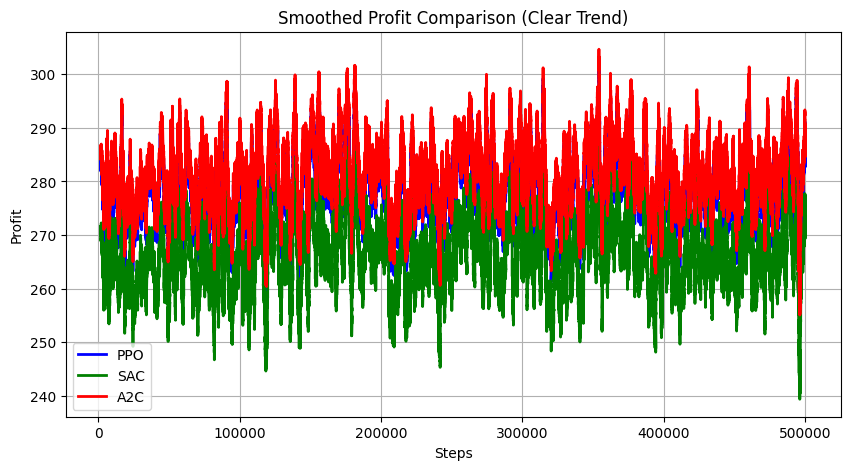

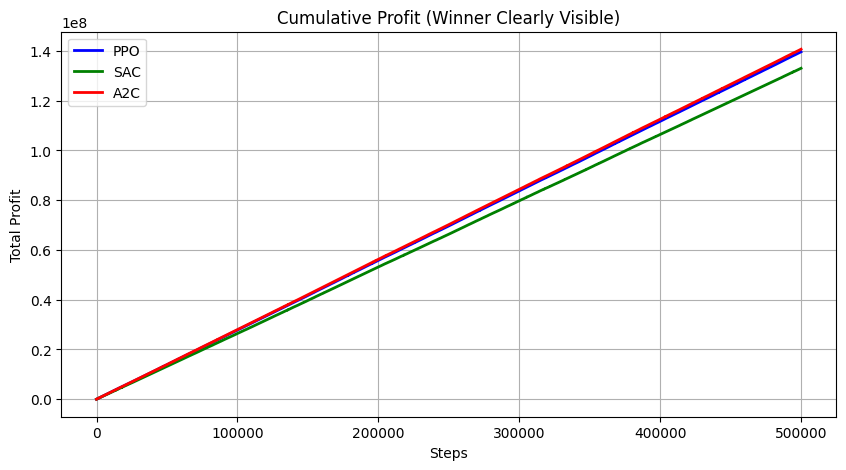

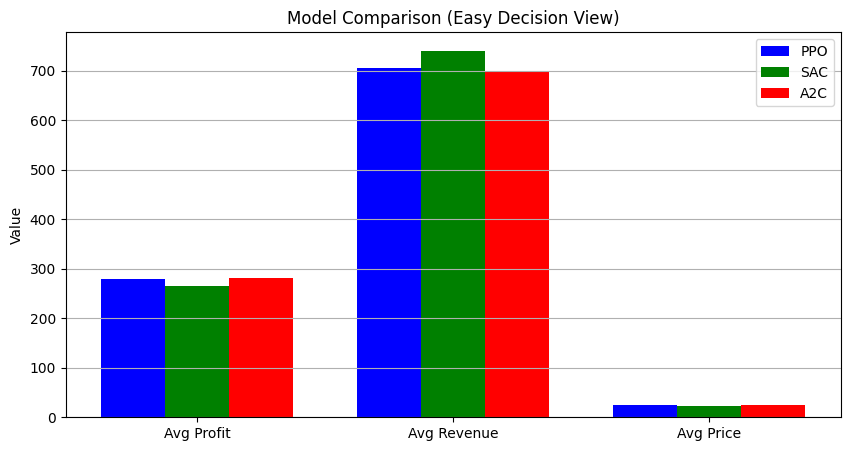

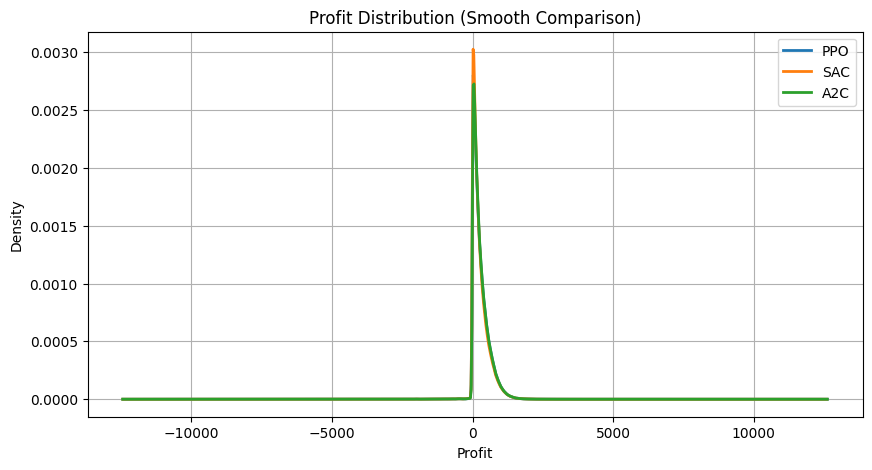

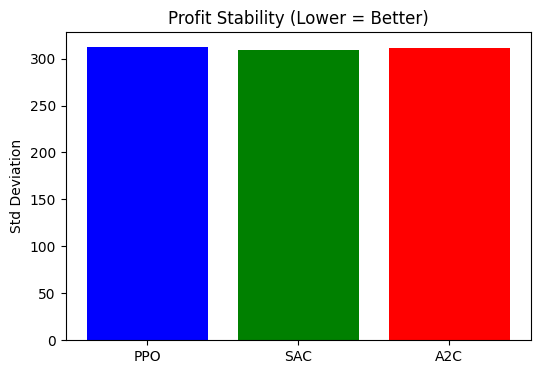

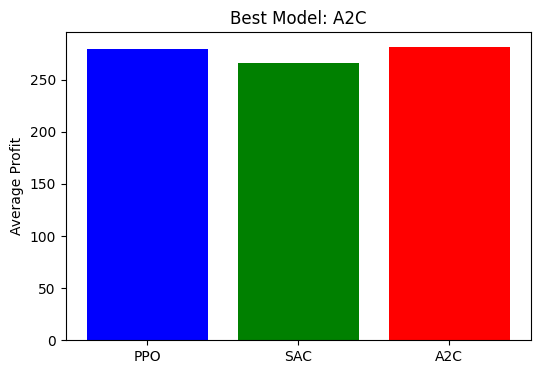


🏆 Best Model: A2C

📉 ===== STABILITY =====
PPO Profit Std Dev: 312.398405192253
SAC Profit Std Dev: 309.27115663789147
A2C Profit Std Dev: 310.97339402670576

📊 ===== SUMMARY TABLE =====
         Metric           PPO           SAC           A2C
0    Avg Profit  2.792585e+02  2.660293e+02  2.813457e+02
1  Total Profit  1.396292e+08  1.330146e+08  1.406728e+08
2   Avg Revenue  7.065871e+02  7.408482e+02  6.985896e+02
3     Avg Price  2.380770e+01  2.250367e+01  2.419414e+01


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# 📂 LOAD ALL MODELS
# ===============================

ppo = pd.read_csv("ppo_rl_simulation_output.csv")
sac = pd.read_csv("sac_rl_simulation_output.csv")
a2c = pd.read_csv("a2c_rl_simulation_output.csv")

print("PPO:", ppo.shape)
print("SAC:", sac.shape)
print("A2C:", a2c.shape)

# Store in dict for cleaner code
models = {
    "PPO": ppo,
    "SAC": sac,
    "A2C": a2c
}

# ===============================
# 📊 BASIC METRICS
# ===============================

print("\n📊 ===== BASIC METRICS =====")

for name, df in models.items():
    print(f"\n{name}:")
    print("Avg Profit:", df["profit"].mean())
    print("Total Profit:", df["profit"].sum())
    print("Avg Revenue:", df["revenue"].mean())
    print("Avg Price:", df["chosen_price"].mean())

# ===============================
# 📊 IMPROVEMENT (BEST MODEL)
# ===============================

avg_profits = {name: df["profit"].mean() for name, df in models.items()}
best_model = max(avg_profits, key=avg_profits.get)

print("\n🏆 Best Model (by Avg Profit):", best_model)

# ===============================
# 📏 ALIGN DATA LENGTH
# ===============================
min_len = min(len(ppo), len(sac), len(a2c))

models = {
    "PPO": ppo.iloc[:min_len],
    "SAC": sac.iloc[:min_len],
    "A2C": a2c.iloc[:min_len]
}

colors = {
    "PPO": "blue",
    "SAC": "green",
    "A2C": "red"
}

# ===============================
# 📊 SMOOTHING FUNCTION
# ===============================
def smooth(series, window=2000):
    return series.rolling(window).mean()

# ===============================
# 📈 1. SMOOTHED PROFIT (BEST GRAPH)
# ===============================
plt.figure(figsize=(10,5))

for name, df in models.items():
    plt.plot(smooth(df["profit"]), label=name, linewidth=2, color=colors[name])

plt.legend()
plt.title("Smoothed Profit Comparison (Clear Trend)")
plt.xlabel("Steps")
plt.ylabel("Profit")
plt.grid(True)
plt.show()

# ===============================
# 🏆 2. CUMULATIVE PROFIT (WHO WINS)
# ===============================
plt.figure(figsize=(10,5))

for name, df in models.items():
    plt.plot(df["profit"].cumsum(), label=name, linewidth=2, color=colors[name])

plt.legend()
plt.title("Cumulative Profit (Winner Clearly Visible)")
plt.xlabel("Steps")
plt.ylabel("Total Profit")
plt.grid(True)
plt.show()

# ===============================
# 📊 3. AVERAGE METRICS BAR (BEST FOR PPT)
# ===============================
labels = ["Avg Profit", "Avg Revenue", "Avg Price"]

values = {
    name: [
        df["profit"].mean(),
        df["revenue"].mean(),
        df["chosen_price"].mean()
    ]
    for name, df in models.items()
}

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(10,5))

for i, (name, vals) in enumerate(values.items()):
    plt.bar(x + (i-1)*width, vals, width, label=name, color=colors[name])

plt.xticks(x, labels)
plt.legend()
plt.title("Model Comparison (Easy Decision View)")
plt.ylabel("Value")
plt.grid(axis='y')
plt.show()

# ===============================
# 📊 4. PROFIT DISTRIBUTION (CLEAN KDE STYLE)
# ===============================
plt.figure(figsize=(10,5))

for name, df in models.items():
    df["profit"].plot(kind="kde", label=name, linewidth=2)

plt.legend()
plt.title("Profit Distribution (Smooth Comparison)")
plt.xlabel("Profit")
plt.grid(True)
plt.show()

# ===============================
# 📊 5. STABILITY (BAR - VERY IMPORTANT)
# ===============================
std_vals = [df["profit"].std() for df in models.values()]

plt.figure(figsize=(6,4))
plt.bar(models.keys(), std_vals, color=["blue","green","red"])
plt.title("Profit Stability (Lower = Better)")
plt.ylabel("Std Deviation")
plt.show()

# ===============================
# 📊 6. FINAL SCORE (BEST MODEL HIGHLIGHT)
# ===============================
avg_profit = {name: df["profit"].mean() for name, df in models.items()}
best_model = max(avg_profit, key=avg_profit.get)

plt.figure(figsize=(6,4))
plt.bar(avg_profit.keys(), avg_profit.values(), color=["blue","green","red"])

plt.title(f"Best Model: {best_model}")
plt.ylabel("Average Profit")
plt.show()

print("\n🏆 Best Model:", best_model)

# ===============================
# 📉 STABILITY (VERY IMPORTANT)
# ===============================

print("\n📉 ===== STABILITY =====")

for name, df in models.items():
    print(f"{name} Profit Std Dev:", df["profit"].std())

# ===============================
# 📊 SUMMARY TABLE
# ===============================

summary = pd.DataFrame({
    "Metric": ["Avg Profit", "Total Profit", "Avg Revenue", "Avg Price"],
    "PPO": [
        ppo["profit"].mean(),
        ppo["profit"].sum(),
        ppo["revenue"].mean(),
        ppo["chosen_price"].mean()
    ],
    "SAC": [
        sac["profit"].mean(),
        sac["profit"].sum(),
        sac["revenue"].mean(),
        sac["chosen_price"].mean()
    ],
    "A2C": [
        a2c["profit"].mean(),
        a2c["profit"].sum(),
        a2c["revenue"].mean(),
        a2c["chosen_price"].mean()
    ]
})

print("\n📊 ===== SUMMARY TABLE =====")
print(summary)